# Desafio de Data Science — Previsão de Preços de Casas (Thiago Miyazaki)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from scipy import stats

In [2]:
# Importar o dataset de preços das casas
df_homes = pd.read_csv('../data/kc_house_data.csv')

# Opcionalmente, importar dados demográficos por CEP
df_zipcode = pd.read_csv('../data/zipcode_demographics.csv')

## Exploração de dados

Primeiro, vamos obter uma visão geral do dataset `kc_house_data.csv`.

In [3]:
# Ver as primeiras linhas
print("=== HEAD ===")
print(df_homes.head())

=== HEAD ===
             id             date     price  bedrooms  bathrooms  sqft_living  \
0  7.129301e+09  20141013T000000  221900.0       3.0       1.00       1180.0   
1  6.414100e+09  20141209T000000  538000.0       3.0       2.25       2570.0   
2  5.631500e+09  20150225T000000  180000.0       2.0       1.00        770.0   
3  2.487201e+09  20141209T000000  604000.0       4.0       3.00       1960.0   
4  1.954401e+09  20150218T000000  510000.0       3.0       2.00       1680.0   

   sqft_basement  sqft_lot  sqft_above  floors  ...  view  condition  grade  \
0            0.0    5650.0      1180.0     1.0  ...   0.0        3.0    7.0   
1          400.0    7242.0      2170.0     2.0  ...   0.0        3.0    7.0   
2            0.0   10000.0       770.0     1.0  ...   0.0        3.0    6.0   
3          910.0    5000.0      1050.0     1.0  ...   0.0        5.0    7.0   
4            0.0    8080.0      1680.0     1.0  ...   0.0        3.0    8.0   

   yr_built  yr_renovated  zipc

In [4]:
# Informações sobre tipos de dados das colunas e valores nulos
print("\n=== INFO ===")
print(df_homes.info())


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 21614 entries, 0 to 21613
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  float64
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  float64
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  float64
 6   sqft_basement  21613 non-null  float64
 7   sqft_lot       21613 non-null  float64
 8   sqft_above     21613 non-null  float64
 9   floors         21613 non-null  float64
 10  waterfront     21613 non-null  float64
 11  view           21613 non-null  float64
 12  condition      21613 non-null  float64
 13  grade          21613 non-null  float64
 14  yr_built       21613 non-null  float64
 15  yr_renovated   21613 non-null  float64
 16  zipcode        21613 non-null  float64
 17  lat            21613 non-null  float64
 18  lon

In [5]:
# Estatísticas descritivas
print("\n=== DESCRIBE ===")
print(df_homes.describe())


=== DESCRIBE ===
                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

       sqft_basement      sqft_lot    sqft_above        floors    waterfront  \
count   21613.000000  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean      291.509045  1.510697e+04   1788.390691      1.494309      0.007542   
std       442.575043  4.142051

In [6]:
# verificando valores nulos
print(df_homes.isna().sum())

id               1
date             1
price            1
bedrooms         1
bathrooms        1
sqft_living      1
sqft_basement    1
sqft_lot         1
sqft_above       1
floors           1
waterfront       1
view             1
condition        1
grade            1
yr_built         1
yr_renovated     1
zipcode          1
lat              1
long             1
sqft_living15    1
sqft_lot15       1
dtype: int64


Vamos buscar entender o significado de cada atributo para avaliarmos a sua relevância na hora de determinar o valor de uma casa:
- `id`: identificar único da casa, dispensável.
- `date`: data da venda (ano de construção é yr_built)
- `price`: preço atual da casa, é a variável alvo que queremos prever.
- `bedrooms`: quantidade de quartos.
- `bathrooms`: quantidade de banheiros.
- `sqft_living`: área construída da casa.
- `sqft_basement`: área do porão.
- `sqft_lot`: área total do terreno.
- `sqft_above`: área construída acima do solo.
- `floors`: quantidade de andares da casa.
- `waterfront`: se a casa tem vista para a água. É uma variável binária.
- `view`: se a casa tem vista para algo interessante. Seus valores variam de 0 a 4.
- `condition`: condição da casa, variando de 1 a 5.
- `grade`: qualidade da construção da casa, variando de 1 a 13.
- `yr_built`: ano de construção da casa.
- `yr_renovated`: ano da última reforma da casa. Se a casa nunca foi reformada, o valor é 0.
- `zipcode`: CEP da casa.
- `lat`: latitude da casa.
- `long`: longitude da casa.
- `sqft_living15`: área construída média das 15 casas mais próximas.
- `sqft_lot15`: área média do terreno das 15 casas mais próximas.

**Estatísticas e observações**:

- Contém 21 atributos, e 21614 linhas.
    - Existem valores nulos, mas são poucos, então podemos simplesmente dropar estas linhas.
- Em nenhuma das colunas existe valores nulos.
- Diversos atributos como `waterfront`, `view`, `condition` e `grade` representam valores categóricos já codificados numericamente (_encoding_), de forma ordinal (com exceção de `waterfront`, que é binária).
- `date` possui dtype `string`, o que é um impeditivo para a regressão linear. Além disso, pela análise dos seus valores, percebemos que ele pode ser convertido para dtype `datetime`. Desta forma, podemos extrair o ano e mês da venda e descartar a informação de dia e horário, que provavelmente não são tão relevantes para a modelagem.
- Já podemos eliminar o atributo `id` prontamente.


In [7]:
# primeiro, vamos dropar o valor nulo
df_homes = df_homes.dropna()

# vamos remover a coluna id
df_homes.drop(columns="id", inplace=True)

# remover linhas com zipcode nulo (apenas 1 linha problemática)
df_homes = df_homes.dropna(subset=['zipcode'])

    # vamos converter os valores de date para datetime
df_homes['date'] = pd.to_datetime(df_homes['date'], format='%Y%m%dT%H%M%S')

# depois extraímos apenas mês e ano
df_homes["year"] = df_homes["date"].dt.year
df_homes["month"] = df_homes["date"].dt.month

# a idade da casa é um atributo interessante, calculá-la em anos dá um valor mais direto
# do que o ano de sua construção ~ ano da venda - ano da construção
df_homes["house_age"] = df_homes["year"] - df_homes["yr_built"]

# e podemos combiná-las em uma feature apenas, para poupar dimensões
df_homes["year_month"] = df_homes["year"] * 100 + df_homes["month"]

# podemos nos livrar da coluna date
df_homes.drop(columns=["date", "year", "month", "yr_built"], inplace=True)

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_basement'}>,
        <Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'floors'}>],
       [<Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>,
        <Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>],
       [<Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>],
       [<Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'house_age'}>,
        <Axes: title={'center': 'year_month'}>]], dtype=object)

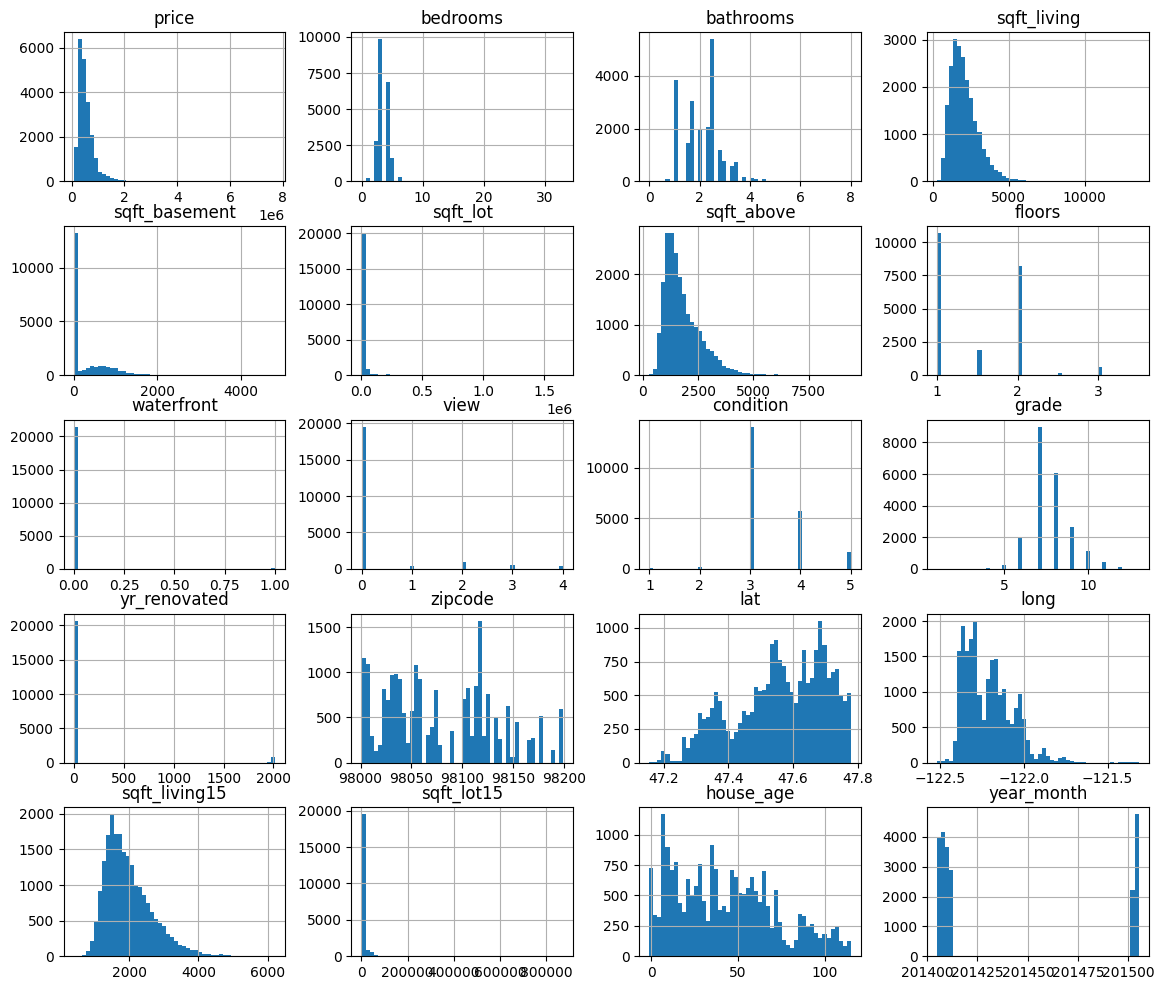

In [8]:
df_homes.hist(figsize=(14,12), bins=50)

Pela leitura dos histogramas, é possível notar que `yr_renovated` possui uma distribuição curiosa, que se assemelha inclusive à das features binárias. De modo que, a quantidade enorme de zeros pode não ser muito útil para a modelagem, e seria mais interessante tratá-la de fato como uma variável binária.

In [9]:
df_homes["was_renovated"] = (df_homes["yr_renovated"] > 0).astype(int)
df_homes.drop(columns="yr_renovated", inplace=True)

Uma hipótese plausível, e que se confirma nos gráficos abaixo, é que casas de preço elevado tendem a se concentrar em bairros específicos, ou seja, criam-se regiões dentro das cidades onde se concentram pessoas de poder elevado de compra, o que leva a um aumento no valor médio das casas da região, e vice-versa.

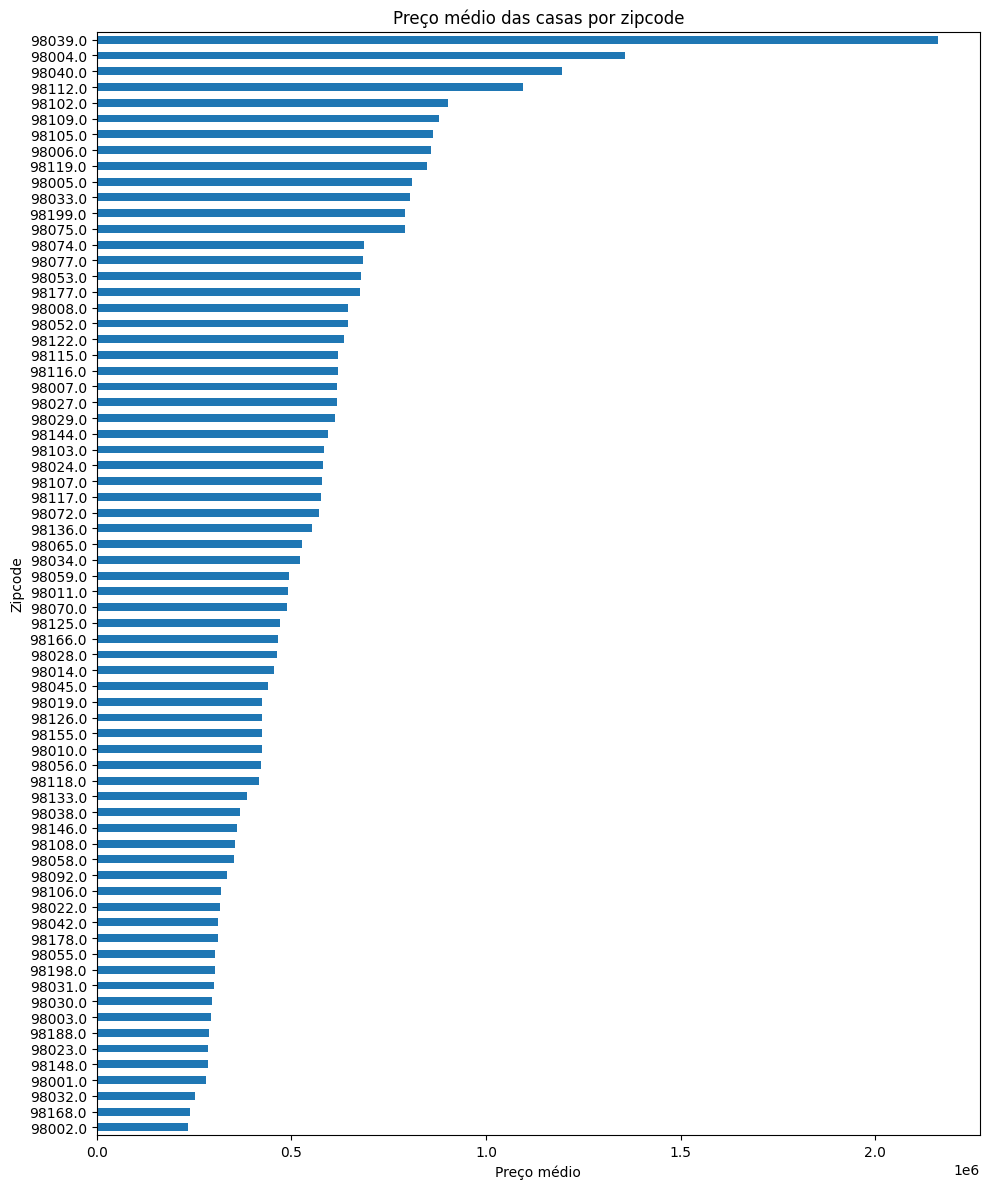

In [10]:
avg_price_by_zipcode = (
    df_homes.groupby("zipcode")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 12))
avg_price_by_zipcode.sort_values().plot(kind="barh")
plt.title("Preço médio das casas por zipcode")
plt.xlabel("Preço médio")
plt.ylabel("Zipcode")
plt.tight_layout()
plt.show()

Agora, vamos verificar o dataset de dados demográficos das áreas por zipcode.

In [11]:
# Ver as primeiras linhas
print("=== HEAD ===")
print(df_zipcode.head())

=== HEAD ===
   ppltn_qty  urbn_ppltn_qty  sbrbn_ppltn_qty  farm_ppltn_qty  non_farm_qty  \
0    38249.0         37394.0              0.0             0.0         855.0   
1    22036.0         22036.0              0.0             0.0           0.0   
2    18194.0         18194.0              0.0             0.0           0.0   
3    21956.0         21956.0              0.0             0.0           0.0   
4    22814.0         22814.0              0.0             0.0           0.0   

   medn_hshld_incm_amt  medn_incm_per_prsn_amt  hous_val_amt  \
0              66051.0                 25219.0      192000.0   
1              91904.0                 53799.0      573900.0   
2              61813.0                 31765.0      246600.0   
3              47461.0                 22158.0      175400.0   
4              48606.0                 28398.0      252600.0   

   edctn_less_than_9_qty  edctn_9_12_qty  ...  per_farm  per_non_farm  \
0                  437.0          2301.0  ...       0.

In [12]:
# Informações sobre tipos de dados e valores nulos
print("\n=== INFO ===")
print(df_zipcode.info())


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ppltn_qty               70 non-null     float64
 1   urbn_ppltn_qty          70 non-null     float64
 2   sbrbn_ppltn_qty         70 non-null     float64
 3   farm_ppltn_qty          70 non-null     float64
 4   non_farm_qty            70 non-null     float64
 5   medn_hshld_incm_amt     70 non-null     float64
 6   medn_incm_per_prsn_amt  70 non-null     float64
 7   hous_val_amt            70 non-null     float64
 8   edctn_less_than_9_qty   70 non-null     float64
 9   edctn_9_12_qty          70 non-null     float64
 10  edctn_high_schl_qty     70 non-null     float64
 11  edctn_some_clg_qty      70 non-null     float64
 12  edctn_assoc_dgre_qty    70 non-null     float64
 13  edctn_bchlr_dgre_qty    70 non-null     float64
 14  edctn_prfsnl_qty        70 non-null     f

In [13]:
# Estatísticas descritivas
print("\n=== DESCRIBE ===")
print(df_zipcode.describe())


=== DESCRIBE ===
          ppltn_qty  urbn_ppltn_qty  sbrbn_ppltn_qty  farm_ppltn_qty  \
count     70.000000       70.000000        70.000000       70.000000   
mean   25655.242857    24543.814286       192.457143       16.442857   
std    11550.597239    12613.622494      1359.783707       59.566948   
min     3037.000000        0.000000         0.000000        0.000000   
25%    19449.500000    18943.500000         0.000000        0.000000   
50%    23926.500000    23298.000000         0.000000        0.000000   
75%    31013.750000    30773.500000         0.000000        0.000000   
max    64181.000000    64181.000000     11176.000000      439.000000   

       non_farm_qty  medn_hshld_incm_amt  medn_incm_per_prsn_amt  \
count     70.000000            70.000000               70.000000   
mean     866.614286         57530.785714            30623.342857   
std     2007.028175         16166.136140            10256.973419   
min        0.000000         32085.000000            17087.000

In [14]:
# verificando valores nulos
print(df_zipcode.isna().sum())

ppltn_qty                 0
urbn_ppltn_qty            0
sbrbn_ppltn_qty           0
farm_ppltn_qty            0
non_farm_qty              0
medn_hshld_incm_amt       0
medn_incm_per_prsn_amt    0
hous_val_amt              0
edctn_less_than_9_qty     0
edctn_9_12_qty            0
edctn_high_schl_qty       0
edctn_some_clg_qty        0
edctn_assoc_dgre_qty      0
edctn_bchlr_dgre_qty      0
edctn_prfsnl_qty          0
per_urbn                  0
per_sbrbn                 0
per_farm                  0
per_non_farm              0
per_less_than_9           0
per_9_to_12               0
per_hsd                   0
per_some_clg              0
per_assoc                 0
per_bchlr                 0
per_prfsnl                0
zipcode                   0
dtype: int64


Os atributos do dataset de dados demográficos por zipcode são:

- `ppltn_qty`: quantidade total de população na região.
- `urbn_ppltn_qty`: quantidade de população urbana.
- `sbrbn_ppltn_qty`: quantidade de população suburbana.
- `farm_ppltn_qty`: quantidade de população rural.
- `non_farm_qty`: quantidade de população não agrícola.
- `medn_hshld_incm_amt`: renda média por domicílio.
- `medn_incm_per_prsn_amt`: renda média por pessoa.
- `hous_val_amt`: valor médio das casas na região.
- `edctn_less_than_9_qty`: quantidade de pessoas com menos de 9 anos de escolaridade.
- `edctn_9_12_qty`: quantidade de pessoas com 9 a 12 anos de escolaridade.
- `edctn_high_schl_qty`: quantidade de pessoas com ensino médio completo.
- `edctn_some_clg_qty`: quantidade de pessoas com alguns anos de faculdade.
- `edctn_assoc_dgre_qty`: quantidade de pessoas com diploma de associado.
- `edctn_bchlr_dgre_qty`: quantidade de pessoas com diploma de bacharel.
- `edctn_prfsnl_qty`: quantidade de pessoas com formação profissional/pós-graduação.
- `per_urbn`: percentual de população urbana.
- `per_sbrbn`: percentual de população suburbana.
- `per_farm`: percentual de população rural.
- `per_non_farm`: percentual de população não agrícola.
- `per_less_than_9`: percentual de pessoas com menos de 9 anos de escolaridade.
- `per_9_to_12`: percentual de pessoas com 9 a 12 anos de escolaridade.
- `per_hsd`: percentual de pessoas com ensino médio completo.
- `per_some_clg`: percentual de pessoas com alguns anos de faculdade.
- `per_assoc`: percentual de pessoas com diploma de tecnólogo.
- `per_bchlr`: percentual de pessoas com diploma de bacharel.
- `per_prfsnl`: percentual de pessoas com formação profissional/pós-graduação.
- `zipcode`: CEP da região.

**Estatísticas e observações**:

- Não existem valores nulos.
- O dataset de zipcodes nos traz informações do perfil demográficos de cada região, como renda média e anos de escolaridade, dados que podem ser muito úteis para a modelagem, visto que o preço das casas é fortemente influenciado por fatores socioeconômicos. E é um fato que áreas com uma maior concentração de pessoas com maior renda e escolaridade tendem a ter preços de casas mais elevados.
- Ambos os datasets possuem a coluna zipcode e o mesmo dtype, permitindo que façamos o merge dos dois datasets para enriquecer os dados de cada casa com as informações demográficas da região onde ela se encontra.
- Temos informações redundantes entre as colunas que representam quantidades e aquelas que são percentuais. É interessante manter as colunas de percentual, visto que elas já es    tão normalizadas e podem ser mais informativas para a modelagem, e também para reduzirmos a dimensionalidade do dataset.
- A coluna `hous_val_amt` representa o valor médio das casas na região, e pode ser uma variável altamente correlacionada com a nossa variável alvo, o que pode levar a data leakage. Pode ser interessante removê-la.


array([[<Axes: title={'center': 'ppltn_qty'}>,
        <Axes: title={'center': 'urbn_ppltn_qty'}>,
        <Axes: title={'center': 'sbrbn_ppltn_qty'}>,
        <Axes: title={'center': 'farm_ppltn_qty'}>,
        <Axes: title={'center': 'non_farm_qty'}>],
       [<Axes: title={'center': 'medn_hshld_incm_amt'}>,
        <Axes: title={'center': 'medn_incm_per_prsn_amt'}>,
        <Axes: title={'center': 'hous_val_amt'}>,
        <Axes: title={'center': 'edctn_less_than_9_qty'}>,
        <Axes: title={'center': 'edctn_9_12_qty'}>],
       [<Axes: title={'center': 'edctn_high_schl_qty'}>,
        <Axes: title={'center': 'edctn_some_clg_qty'}>,
        <Axes: title={'center': 'edctn_assoc_dgre_qty'}>,
        <Axes: title={'center': 'edctn_bchlr_dgre_qty'}>,
        <Axes: title={'center': 'edctn_prfsnl_qty'}>],
       [<Axes: title={'center': 'per_urbn'}>,
        <Axes: title={'center': 'per_sbrbn'}>,
        <Axes: title={'center': 'per_farm'}>,
        <Axes: title={'center': 'per_non_fa

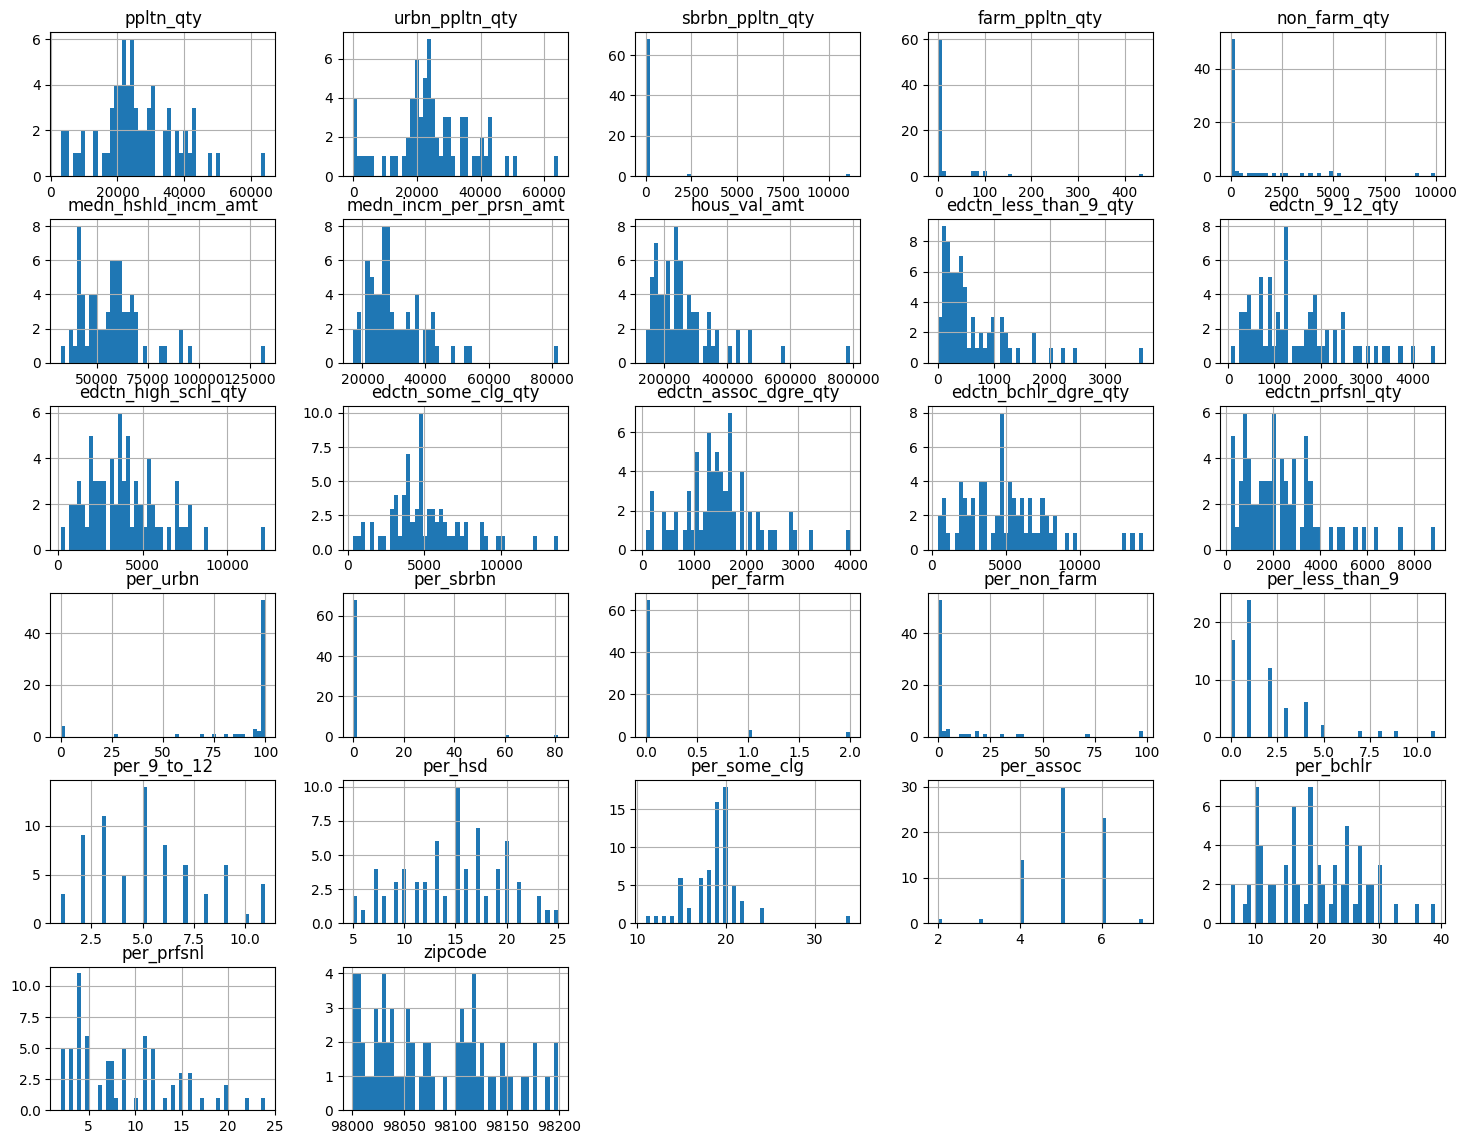

In [15]:
df_zipcode.hist(figsize=(18,14), bins=50)

In [16]:
# mesclando os dois datasets
dfm = df_homes.merge(df_zipcode, on="zipcode", how="left")

Outra hipótese plausível, e que se confirma nos gráficos de preço vs percentuais de níveis educacionais, é que existe uma tendência que o preço das casas suba conforme aumenta a proporção, na região, de pessoas altamente qualificadas academicamente.

/home/thiago/miniconda3/envs/desafio-env/lib/python3.13/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)
/home/thiago/miniconda3/envs/desafio-env/lib/python3.13/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


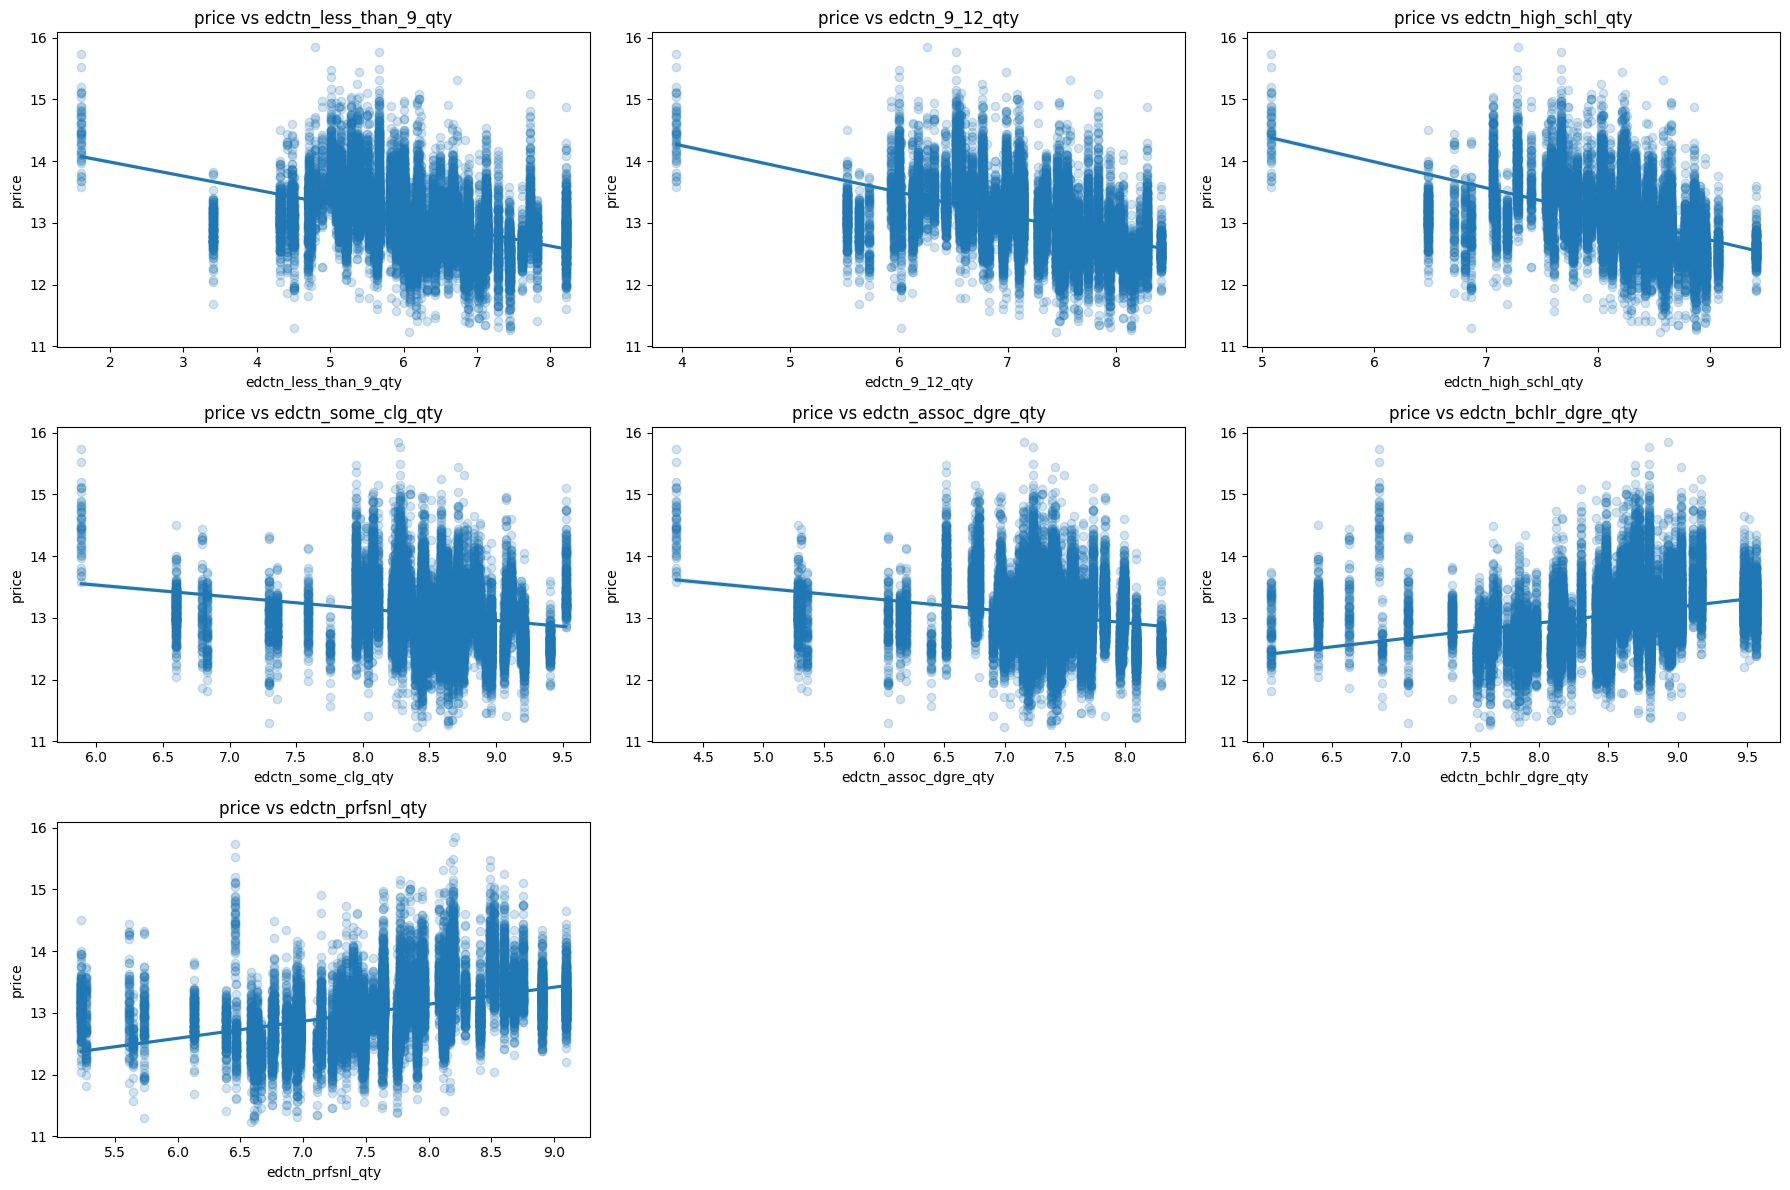

In [17]:
df_edu = np.log1p(dfm.copy())

education_cols = [
    'edctn_less_than_9_qty',
    'edctn_9_12_qty',
    'edctn_high_schl_qty',
    'edctn_some_clg_qty',
    'edctn_assoc_dgre_qty',
    'edctn_bchlr_dgre_qty',
    'edctn_prfsnl_qty'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(education_cols):
    sns.regplot(
        data=df_edu,
        x=col,
        y="price",
        scatter_kws={"alpha": 0.2},
        ax=axes[i]
    )
    axes[i].set_title(f"price vs {col}")

# Remove subplots extras vazios
for j in range(len(education_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
# dropar as colunas com valores absolutos para manter os percentuais e remover hous_val_amt
drop_zipcode_columns = ['urbn_ppltn_qty', 'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty', 'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty', 'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty', 'edctn_prfsnl_qty', 'hous_val_amt']

dfm.drop(columns=drop_zipcode_columns, inplace=True)

# agora podemos remover a coluna zipcode
dfm.drop(columns="zipcode", inplace=True)

### Visualização dos dados

#### Skewness (assimetria) e outliers.

Vamos verificar o skewness de cada atributo, desconsiderando as colunas que não fazem sentido calcularmos o skewness, como as variáveis binárias, ordinais, temporais, geográficas, e percentuais.

Para tal, primeiro vamos selecionar um subconjunto de atributos:

In [19]:
skewness_columns = ['price', 'sqft_living', 'sqft_basement', 'sqft_lot', 'sqft_above', 'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt']

skew_dfm = dfm[skewness_columns]

Vamos visualizar o skewness de cada um desses atributos por meio de histogramas:

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'sqft_living'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_living15'}>],
       [<Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'ppltn_qty'}>,
        <Axes: title={'center': 'medn_hshld_incm_amt'}>],
       [<Axes: title={'center': 'medn_incm_per_prsn_amt'}>, <Axes: >,
        <Axes: >]], dtype=object)

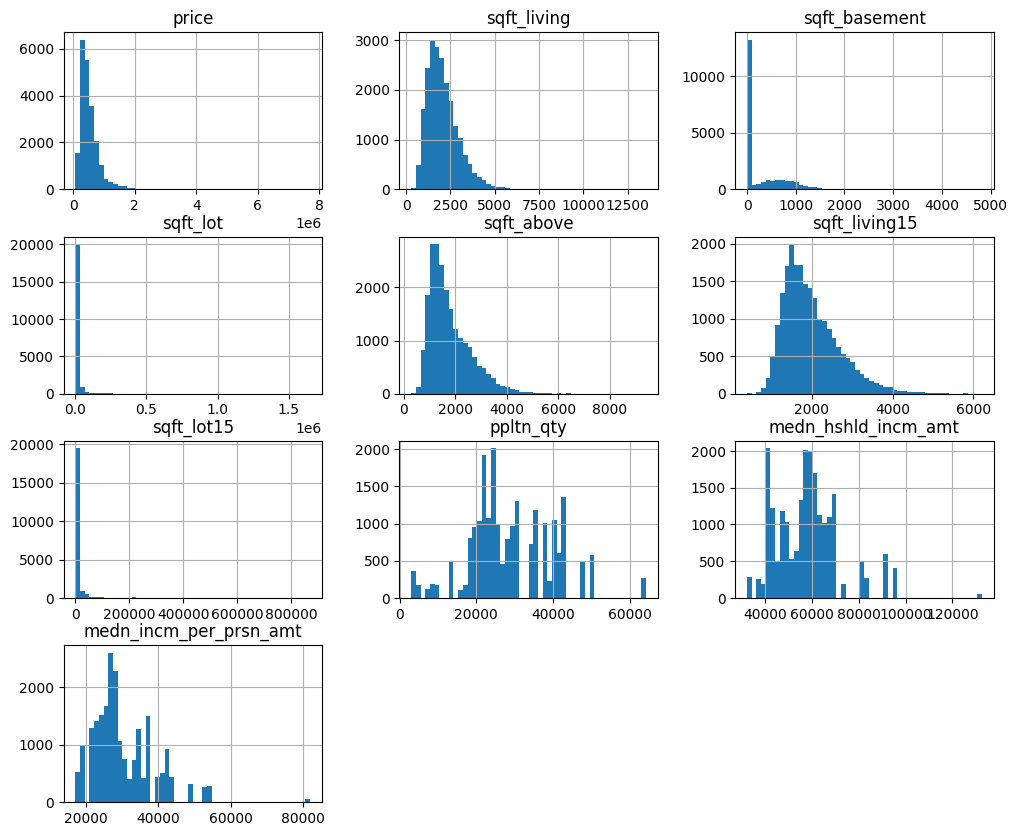

In [20]:
skew_dfm.hist(figsize=(12,10), bins=50)

É possível notar que a maioria deles possui assimetria à direita (right skew). Para tarefas de regressão linear, devemos aplicação Log-transform para tentar aproximar os dados de uma distribuição normal.

In [21]:
skew_dfm_log = np.log1p(skew_dfm)

Com os valores aproximados a uma distribuição normal, podemos normalizá-los e plotar os boxplots para verificar a presença de outliers.

<Axes: >

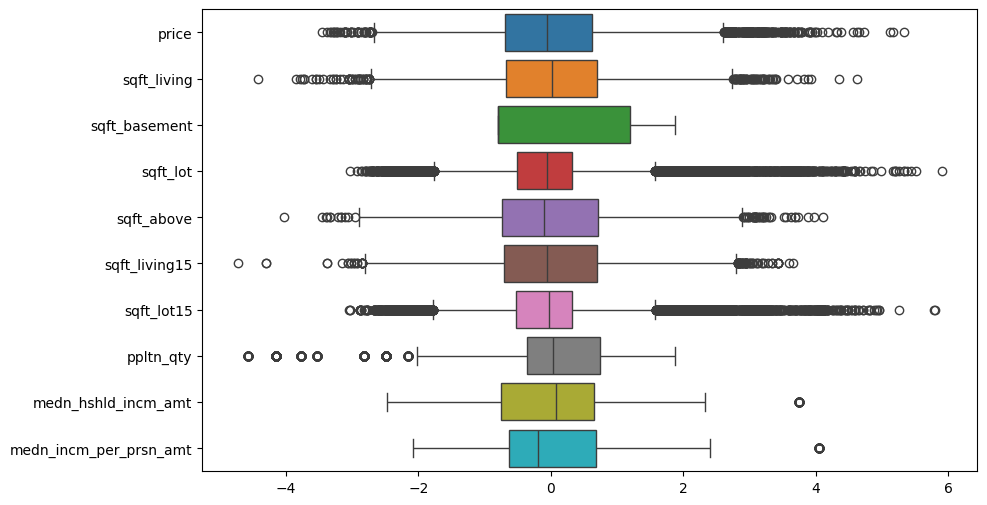

In [22]:
# normalizar valores
scaler = StandardScaler()
df_norm = pd.DataFrame(scaler.fit_transform(skew_dfm_log), columns=skew_dfm_log.columns)

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_norm, orient="h")

Pela leitura dos boxplots, é possível perceber a presença de muitos outliers, especialmente na variável `price`, que é a nossa variável alvo. Por tentativa e erro, definimos o threshold de z-score para 3.5, para não removermos muitas linhas do dataframe.

In [23]:
# cria uma lista de linhas a serem mantidas
# .all(axis=1) verifica se todos os itens numa linha são true, se um valor for false, a linha é removida
z_scores_mask = (np.abs(stats.zscore(skew_dfm_log)) <= 7).all(axis=1)
skew_dfm_log_no_out = skew_dfm_log[z_scores_mask].copy()    # novo dataset com linhas removidas e log-transform
dfm_no_out = dfm[z_scores_mask].copy()                      # remove as mesmas linhas do dataset original
dfm_no_out[skewness_columns] = skew_dfm_log_no_out          # atualiza as colunas selecionadas do df merged com valores log-transformed

print(f"Total de linhas antes da remoção: {len(dfm)}")
print(f"Total de linhas removidas do DF: {len(dfm) - len(dfm_no_out)}")
print(f"Porcentagem de linhas removidas: {(len(dfm) - len(dfm_no_out))/len(dfm) * 100:.2f}")

Total de linhas antes da remoção: 21613
Total de linhas removidas do DF: 0
Porcentagem de linhas removidas: 0.00


#### Correlação

Vamos observar o heatmap da matriz de correlação.

<Axes: >

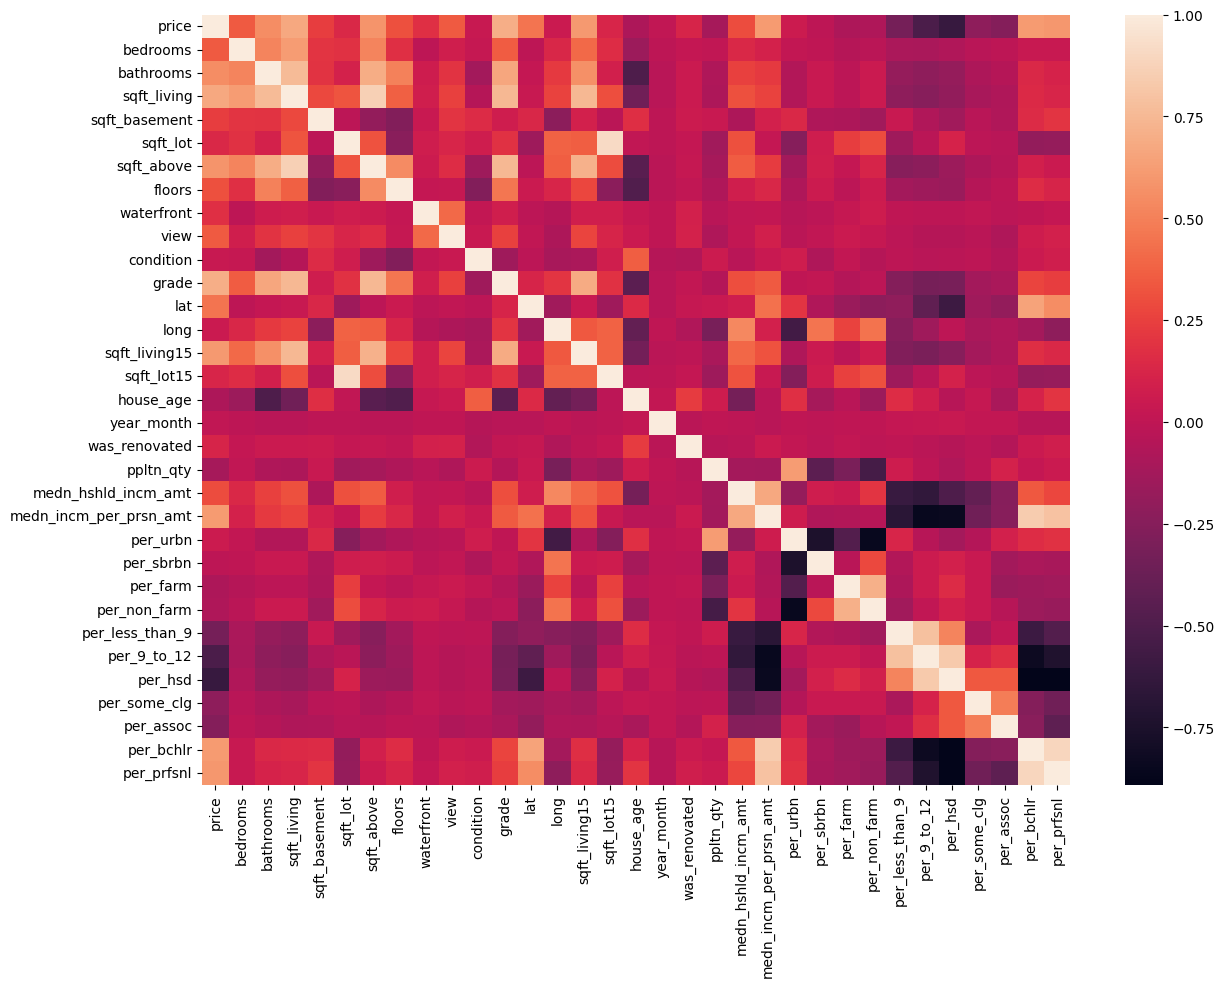

In [24]:
plt.figure(figsize=(14, 10))
sns.heatmap(dfm_no_out.corr(numeric_only=True))

Vamos plotar também os coeficientes de correlação entre os atributos e a variável alvo.

Text(0, 0.5, 'atributos')

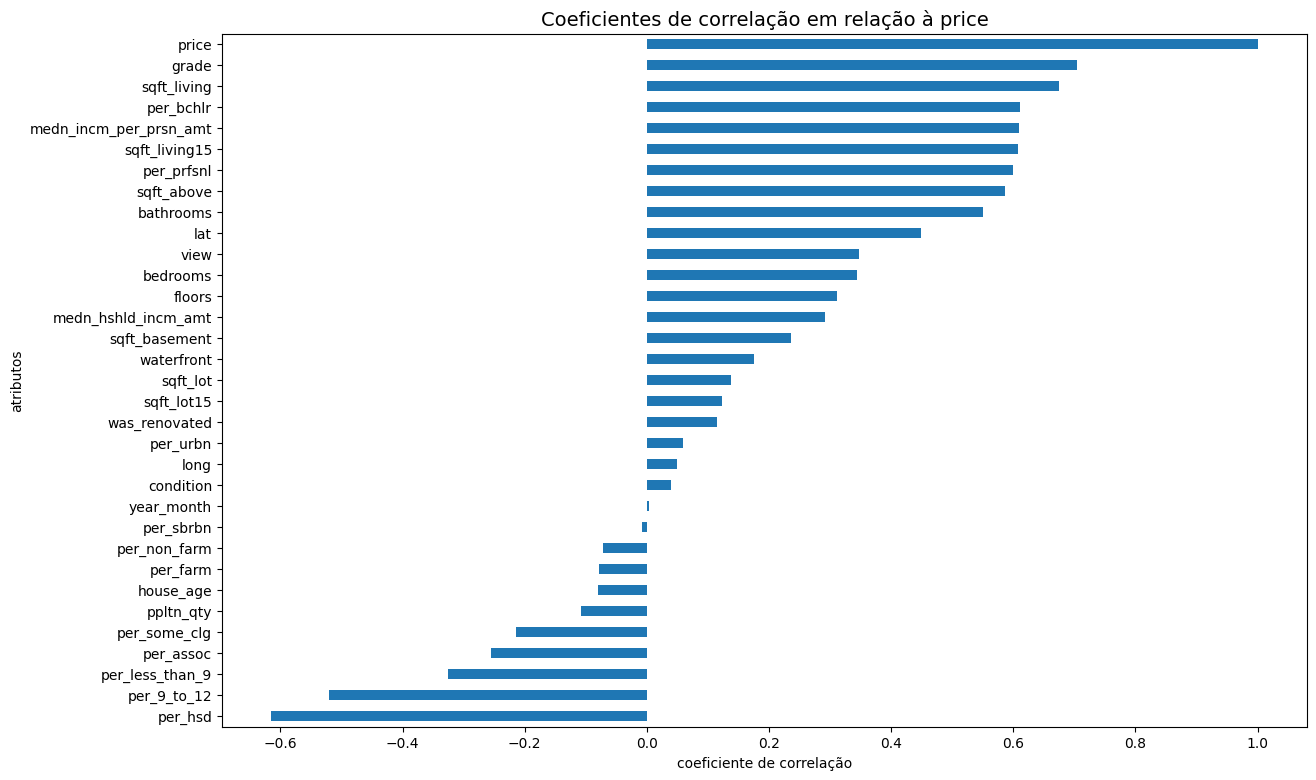

In [25]:
ax = dfm_no_out.corr()['price'].sort_values().plot(kind='barh', figsize=(14,9))
ax.set_title('Coeficientes de correlação em relação à price', fontsize=14)
ax.set_xlabel('coeficiente de correlação')
ax.set_ylabel('atributos')

## Importância das features

Vamos treinar o modelo Lasso e extrair os coeficientes para verificar a importância de cada atributo na determinação do preço das casas.

Para tal, precisamos:
- Fazer o splits dos dados em treino e teste
- Separar colunas numéricas das binárias para aplicar o scaler apenas nas numéricas
- Normalizar os dados para não haver escalas muito divergentes entre os atributos
- Treinar o modelo LassoCV, que já faz a cross-validation com valores alpha otimizados
- Extrair as métricas e os coeficientes de cada atributo para verificar a importância de cada um deles

In [26]:
X = dfm_no_out.drop(columns=["price"])
y = dfm_no_out["price"]

# split dos dados entre treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# separar as colunas binárias e numéricas
binary_cols = ["waterfront", "was_renovated"]
numeric_cols = [c for c in X.columns if c not in binary_cols]

# passar o scaler somente nas variáveis numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_num", StandardScaler(), numeric_cols),
        ("keep_bin", "passthrough", binary_cols),
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

# criar um pipeline para treinamento do lassocv
# - alpha é o hiperparâmetro que dita a tendência com que os
# coeficientes tendem a zero
# - o alpha não é linear, logo valores pequenos tem alto impacto
# e valores grandes tem impacto menor, logo é interessante usar
# escala logarítmica
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("lasso", LassoCV(
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        alphas=np.logspace(-4, 1, 200),
        max_iter=20000,
        random_state=42
    ))
])

# treinar o modelo e fazer as previsões
lasso_pipeline.fit(X_train, y_train)
y_pred = lasso_pipeline.predict(X_test)

# criando um df com os nomes das colunas, e os coeficientes associados
lasso_model = lasso_pipeline.named_steps["lasso"]
feature_names = lasso_pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": lasso_model.coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print("Melhor alpha:", lasso_pipeline.named_steps["lasso"].alpha_)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print(coef_df)

Melhor alpha: 0.0001
R²: 0.8627863107049145
MAE: 0.14815702753465992
RMSE: 0.19776280093791523
                   feature      coef  abs_coef
30              waterfront  0.428011  0.428011
28               per_bchlr  0.137412  0.137412
9                    grade  0.123237  0.123237
18  medn_incm_per_prsn_amt  0.093419  0.093419
29              per_prfsnl  0.092620  0.092620
23         per_less_than_9  0.089748  0.089748
2              sqft_living  0.089522  0.089522
5               sqft_above  0.083420  0.083420
31           was_renovated  0.068285  0.068285
10                     lat  0.066170  0.066170
12           sqft_living15  0.052589  0.052589
24             per_9_to_12  0.052302  0.052302
4                 sqft_lot  0.050540  0.050540
7                     view  0.045860  0.045860
26            per_some_clg  0.044306  0.044306
1                bathrooms  0.038440  0.038440
8                condition  0.036080  0.036080
25                 per_hsd -0.032356  0.032356
16          

Vamos dropar a coluna `per_urbn`, que tem um coeficiente igual a zero.

In [27]:
X_train.drop(columns=["per_urbn"], inplace=True)
X_test.drop(columns=["per_urbn"], inplace=True)

Por fim, chegamos à conclusão que as oito features mais importantes são:
- waterfront
- per_bchlr
- grade
- medn_incm_per_prsn_amt
- per_prfsnl
- per_less_than_9
- sqft_living
- sqft_above


## Treinamento do baseline (Linear Regression) e Cross-validation

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

test_score = model.score(X_test, y_test)

print(f"Linear Regression Score: {test_score}")
y_pred = model.predict(X_test)

y_test = np.expm1(y_test)
y_pred = np.expm1(y_pred)

print("R² (pós-exp):", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(f"Cross-validation Scores: {cv_scores}")
print(cv_scores.mean())

Linear Regression Score: 0.8628257881617731
R² (pós-exp): 0.8433905185383279
MAE: 85125.4787962372
RMSE: 153869.12138446336
Cross-validation Scores: [0.86395633 0.8603799  0.85883493 0.85937732 0.85626281]
0.8597622586346887


Como o R² score do modelo está próximo à média dos scores da cross-validation, parece indicar que o modelo não está sofrendo de overfitting, e tem uma boa capacidade de generalização. Agora, com um baseline sólido, podemos criar um pipeline de treinamento para testar outros modelos e comparar os resultados.